In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px

In [109]:
# add data set
space_df = pd.read_csv("data/Master_Space_Data_All.txt")
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success


In [110]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5315 non-null   float64
 6   Status Mission  5315 non-null   object 
dtypes: float64(1), object(6)
memory usage: 291.0+ KB


In [111]:
# convert into numeric, removing commas and coercing errors to NaN
space_df['Price'] = pd.to_numeric(space_df['Price'].astype(str).str.replace(',', ''), errors='coerce')

In [112]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5315 non-null   float64
 6   Status Mission  5315 non-null   object 
dtypes: float64(1), object(6)
memory usage: 291.0+ KB


In [113]:
# fill NaN values with 0 and convert to float
space_df['Price'] = space_df['Price'].fillna(0).astype(float)

In [114]:
print(space_df.columns)

Index(['Company Name', 'Location', 'Datum', 'Detail', 'Status Rocket', 'Price',
       'Status Mission'],
      dtype='object')


In [115]:
# extract country from Location column
space_df['countries'] = space_df['Location'].str.split(',').str[-1].str.strip()

In [116]:
# take states out of USA
usa_states = ['CA', 'FL', 'TX', 'Texas', 'New Mexico', 'Virginia']
space_df['countries'] = space_df['countries'].replace(usa_states, 'USA')

In [117]:
print(space_df[['Location', 'countries']].head())

                                 Location countries
0              SLC-4E, Vandenberg SFB, CA       USA
1          SLC-40, Cape Canaveral SFS, FL       USA
2              SLC-4E, Vandenberg SFB, CA       USA
3  Xichang Satellite Launch Center, China     China
4          SLC-40, Cape Canaveral SFS, FL       USA


In [118]:
# extract year from Datum column using regex
def extract_year(text):
    if pd.isna(text):
        return None
    match = re.search(r'(19\d{2}|20\d{2})', str(text))
    return int(match.group(1)) if match else None

space_df['date'] = space_df['Datum'].apply(extract_year)

In [119]:
# convert date to Int64 
space_df['date'] = space_df['date'].astype('Int64')

In [120]:
#adding lat and lon columns

location_coords = {
    "Plesetsk Cosmodrome": [64.6970, 40.2320],
    "Cape Canaveral": [28.4962, -80.5772],
    "Baikonur Cosmodrome": [45.9697, 63.3042],
    "Vandenberg SFB": [34.6370, -120.6146],
    "Vandenberg AFB": [34.6370, -120.6146],
    "Vandenberg": [34.6370, -120.6146],
    "French Guiana": [5.2380, -52.7762],
    "Kennedy Space Center": [28.5746, -80.6520],
    "Jiuquan": [40.9861, 100.2083],
    "Xichang": [27.9006, 102.2435],
    "Kapustin Yar": [48.6437, 45.7721],
    "Taiyuan": [38.8487, 111.6080],
    "Tanegashima": [30.4018, 130.9774],
    "Sriharikota": [13.7406, 80.2340],
    "Uchinoura": [31.2515, 131.0762],
    "Wallops Flight Facility": [37.9342, -75.4724],
    "Mahia Peninsula": [-39.2380, 177.8746],
    "Mahia, New Zealand": [-39.2380, 177.8746],
    "Wenchang": [19.5768, 110.7480],
    "Corn Ranch": [31.4230, -104.7571],
    "Vostochny Cosmodrome": [51.8495, 128.3552],
    "Semnan": [35.9543, 53.8075],
    "Yellow Sea": [36.7039, 121.2359],
    "Palmachim": [31.9064, 34.6933],
    "Kwajalein Atoll": [8.9836, 167.5780],
    "Kodiak Launch Complex": [57.4309, -152.3563],
    "Starbase": [25.9923, -97.1848],
    "San Marco Platform": [-2.9955, 40.1948],
    "Woomera": [-31.0688, 136.4426],
    "Point Mugu": [34.0870, -119.0610],
    "Edwards AFB": [34.9175, -117.8912],
    "Naro Space Center": [34.4536, 127.5179],
    "Spaceport America": [32.9903, -106.9750],
    "Hammaguir": [30.8678, -3.0436],
    "Mojave Air and Space Port": [35.0293, -118.1059],
    "Sohae": [39.6683, 124.7070],
    "Gran Canaria": [27.9252, -15.6214],
    "S. Korea": [36.6432, 127.2068]
}

# 2. Define a function to find the match
def get_lat_lon(loc_string):
    for key, coords in location_coords.items():
        if key.lower() in str(loc_string).lower():
            return pd.Series(coords)
    return pd.Series([None, None])

# 3. Apply the function to create 'Lat' and 'Lon' columns
# Assuming your dataframe is named 'space_df' and has a column 'Location'
space_df[['Lat', 'Lon']] = space_df['Location'].apply(get_lat_lon)

In [121]:
unique_companies = space_df['Company Name'].unique()
print(unique_companies)

['SpaceX' 'CASC' 'Arianespace' 'ULA' 'Rocket Lab' 'Blue Origin'
 'Galactic Energy' 'ISRO' 'VKS' 'Roscosmos' 'AST SpaceMobile' 'JAXA' 'ESA'
 'Firefly' 'ExPace' 'LandSpace' 'SIAS' 'KARI' 'ISA' 'Firefly Aerospace'
 'Northrop Grumman' 'Isar Aerospace' 'CAS Space' 'Orienspace' 'i-Space'
 'CGSTL' 'NADA' 'Space One' 'China Rocket' 'IRGC' 'MHI' 'Amazon/ULA'
 'Relativity Space' 'ABL Space' 'Virgin Orbit' 'NASA' 'Astra' 'NASA/ESA'
 'Northrop' 'IAI' 'VKS RF' 'Exos' 'ILS' 'OneSpace' 'Landspace' 'Eurockot'
 'Land Launch' 'CASIC' 'KCST' 'Sandia' 'Kosmotras' 'Khrunichev'
 'Sea Launch' 'Boeing' 'ISAS' 'SRC' 'MITT' 'Lockheed' 'AEB' 'Starsem' 'ed'
 'RVSN USSR' 'EER' 'General Dynamics' 'Martin Marietta' 'Yuzhmash'
 'Douglas' 'smodrome' 'ASI' 'US Air Force' 'CNES' 'z U | Cosmos 670'
 'CECLES' 'RAE' 'UT' 'OKB-586' 'AMBA' "Arm??e de l'Air" 'US Navy']


In [122]:
# add provider
def categorize_provider(company):
    commercial_keywords = ['SpaceX', 'Arianespace', 'ULA', 'Rocket Lab', 'Blue Origin', 
    'Galactic Energy', 'AST SpaceMobile', 'Firefly Aerospace', 'ExPace', 
    'LandSpace', 'Isar Aerospace', 'Orienspace', 'i-Space', 'CGSTL', 
    'Amazon/ULA', 'Relativity Space', 'ABL Space', 'Virgin Orbit', 
    'Astra', 'Northrop Grumman', 'ILS', 'OneSpace', 'Eurockot', 
    'Kosmotras', 'Sea Launch', 'Boeing', 'Lockheed', 'Starsem', 
    'General Dynamics', 'Martin Marietta'    ]
    # Check if any keyword exists in the Company Name string
    if any(keyword.lower() in str(company).lower() for keyword in commercial_keywords):
        return 'Commercial'
    return 'State'

space_df['provider'] = space_df['Company Name'].apply(categorize_provider)

In [123]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date,Lat,Lon,provider
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146,Commercial
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772,Commercial
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146,Commercial
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success,China,2026,27.9006,102.2435,State
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772,Commercial


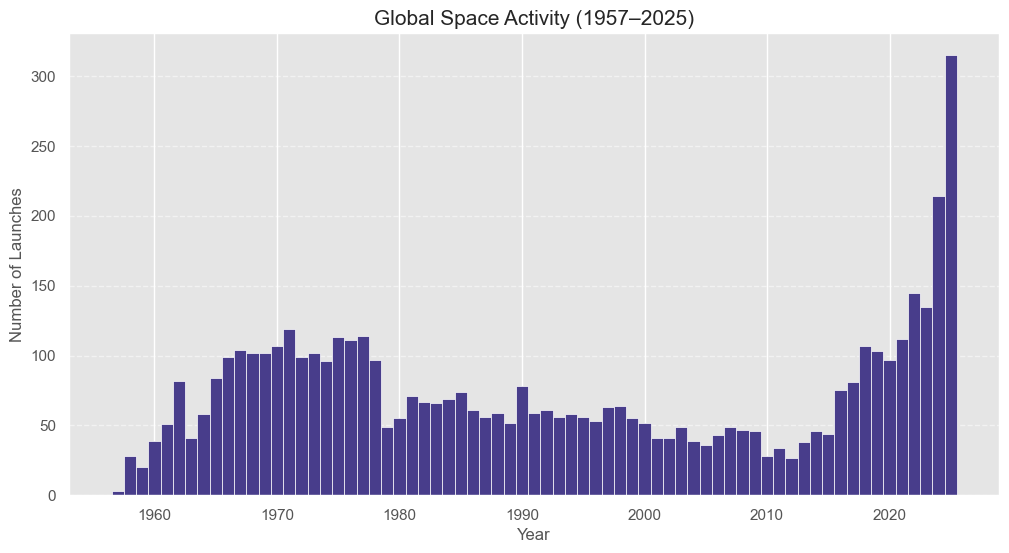

In [124]:
df_filtered = space_df[space_df['date'] <= 2025]

# 3. Plot the distribution
plt.figure(figsize=(12, 6))
min_yr, max_yr = int(df_filtered['date'].min()), int(df_filtered['date'].max())

plt.hist(df_filtered['date'], bins=range(min_yr, max_yr + 2), 
         color='darkslateblue', edgecolor='white', align='left')

plt.title('Global Space Activity (1957–2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

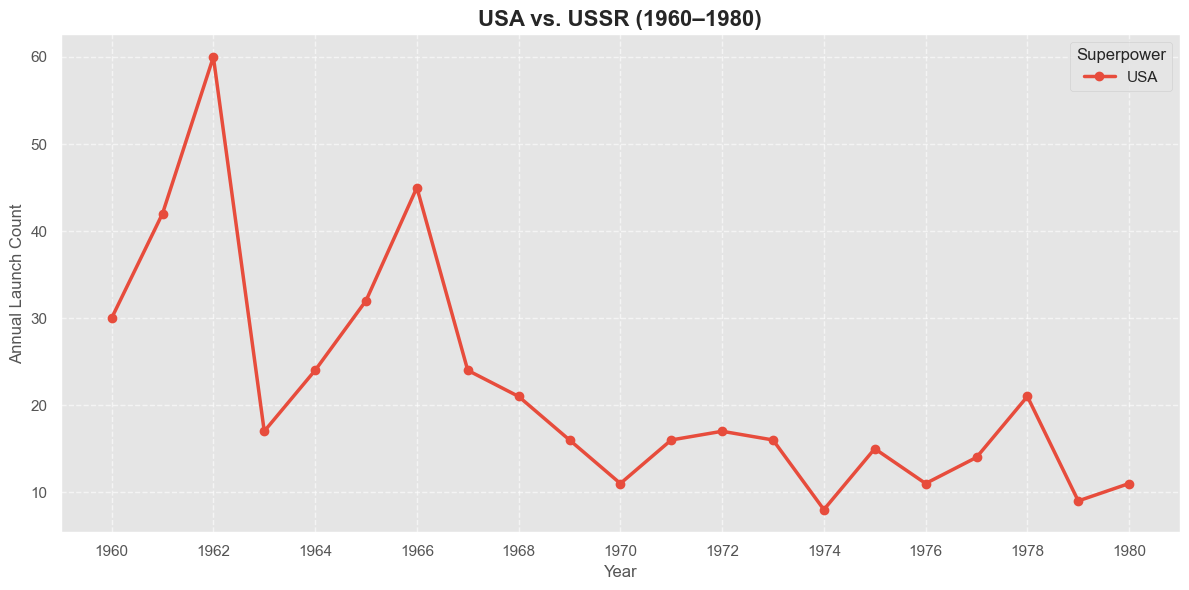

In [125]:
# 1. Filtering for the specific era (1960-1980) and the two rivals
# Note: Using 'Russia/USSR' to catch all iterations of the Soviet/Russian program
era_df = space_df[(space_df['date'] >= 1960) & (space_df['date'] <= 1980)]
rivals_df = era_df[era_df['countries'].isin(['USA', 'Russia/USSR'])]

# 2. Pivot the data to get annual counts for each
# This creates a table where 'date' is the index and 'USA'/'Russia/USSR' are columns
pivot_rivals = rivals_df.groupby(['date', 'countries']).size().unstack(fill_value=0)

# 3. Create the Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting with specific colors (Blue for USA, Red for USSR)
pivot_rivals.plot(kind='line', marker='o', linewidth=2.5, ax=ax, color=['#e74c3c', '#3498db'])

# 4. Formatting for clarity
ax.set_title('USA vs. USSR (1960–1980)', fontsize=16, fontweight='bold')
ax.set_ylabel('Annual Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_xticks(range(1960, 1981, 2)) # Show every 2 years on the axis
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="Superpower")

plt.tight_layout()
plt.show()

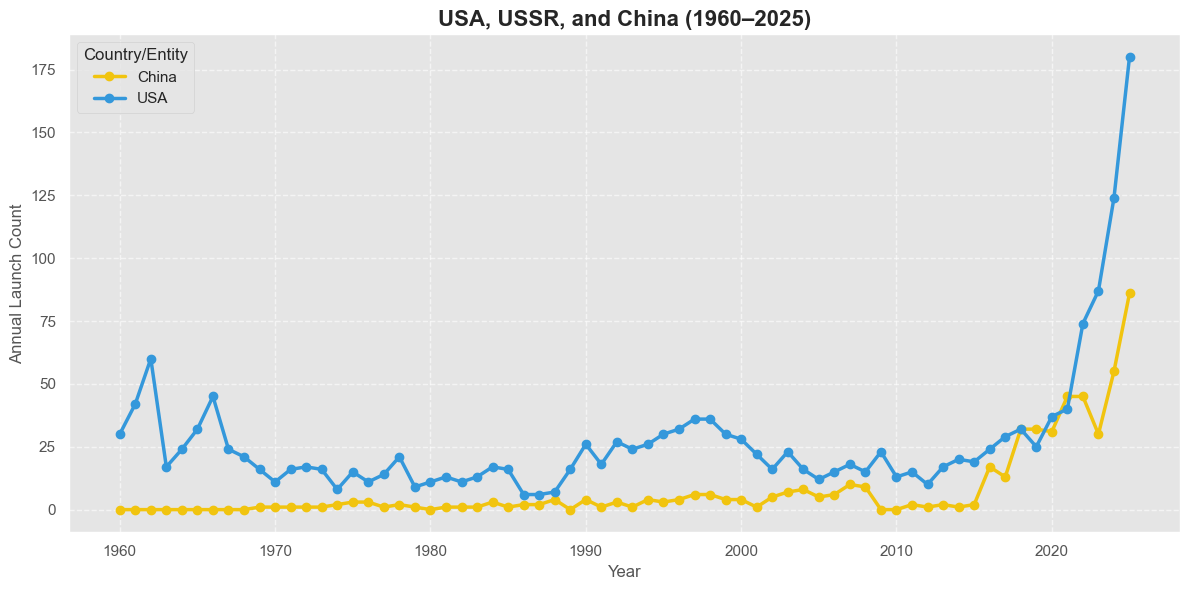

In [126]:
# 1. Filtering for the specific era (1960-1980) and the three nations
# Corrected the date logic to focus on the 1960-1980 window
era_df = space_df[(space_df['date'] >= 1960) & (space_df['date'] <= 2025)]
# Added 'China' to the filter list
nations_df = era_df[era_df['countries'].isin(['USA', 'Russia/USSR', 'China'])]

# 2. Pivot the data to get annual counts for each
pivot_nations = nations_df.groupby(['date', 'countries']).size().unstack(fill_value=0)

# 3. Create the Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))

# Updated colors: Red for USSR, Blue for USA, Gold/Yellow for China
# Note: The order of colors in the list should match the alphabetical order of the columns 
# (China, Russia/USSR, USA) or you can map them specifically.
colors = {'China': '#f1c40f', 'Russia/USSR': '#e74c3c', 'USA': '#3498db'}
pivot_nations.plot(kind='line', marker='o', linewidth=2.5, ax=ax, color=[colors[col] for col in pivot_nations.columns])

# 4. Formatting for clarity
ax.set_title('USA, USSR, and China (1960–2025)', fontsize=16, fontweight='bold')
ax.set_ylabel('Annual Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_xticks(range(1960, 2026, 10)) 
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="Country/Entity")

plt.tight_layout()
plt.show()

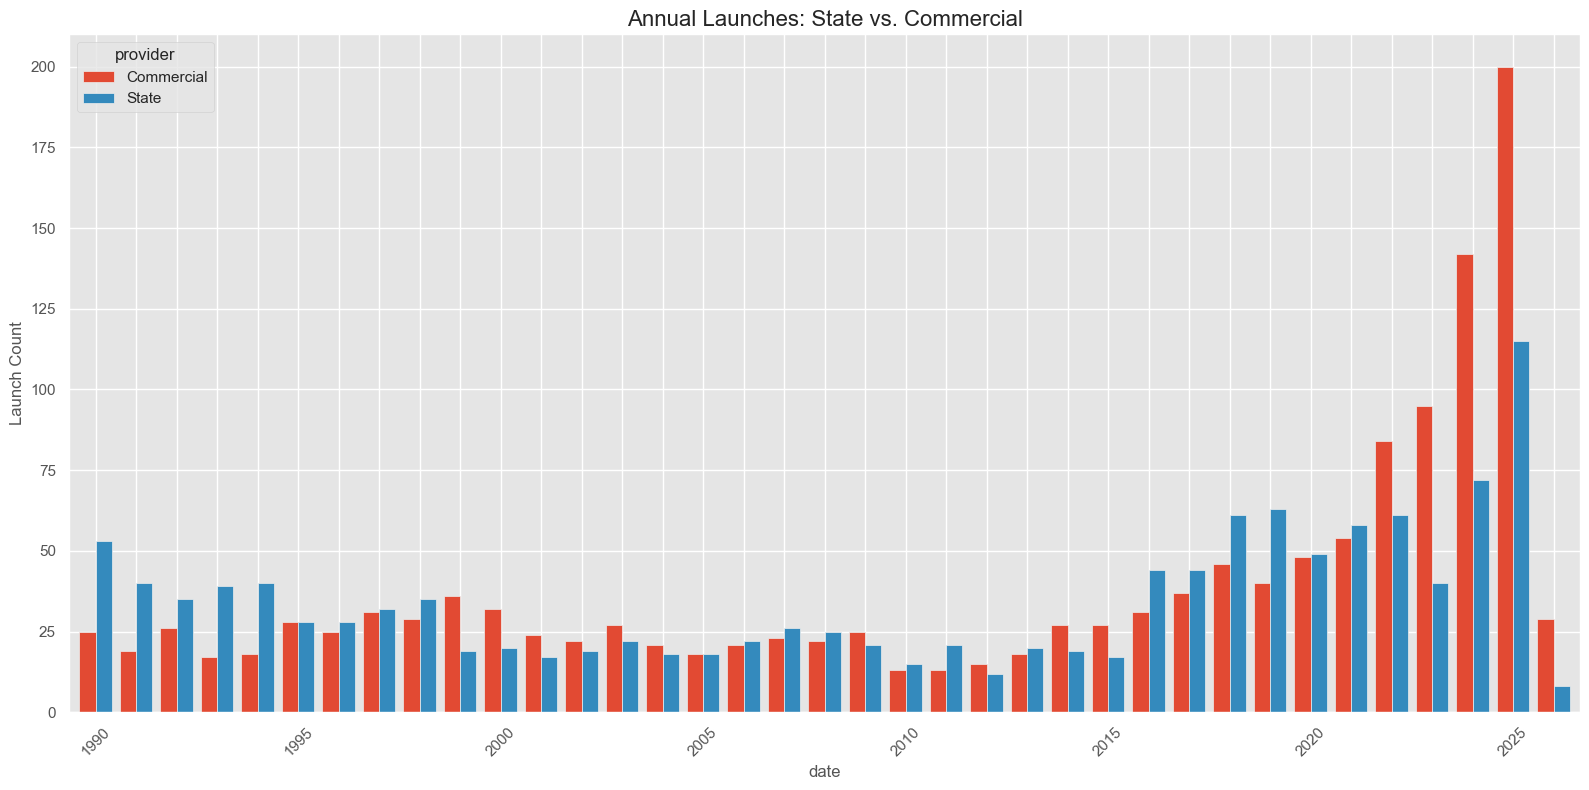

In [127]:
# 1. Filter for the date range
df_modern = space_df[(space_df['date'] >= 1990) & (space_df['date'] <= 2026)].copy()

# 2. Pivot using the existing 'Provider' column
# This creates a table where 'date' is the row and 'State'/'Commercial' are the columns
pivot_sector = df_modern.groupby(['date', 'provider']).size().unstack(fill_value=0)

# 3. Create the bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# stacked=False puts the State and Commercial bars side-by-side
pivot_sector.plot(kind='bar', stacked=False, ax=ax, width=0.8)

# 4. Clean up the labels so they don't overlap
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

# Formatting
ax.set_title('Annual Launches: State vs. Commercial', fontsize=16)
ax.set_ylabel('Launch Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

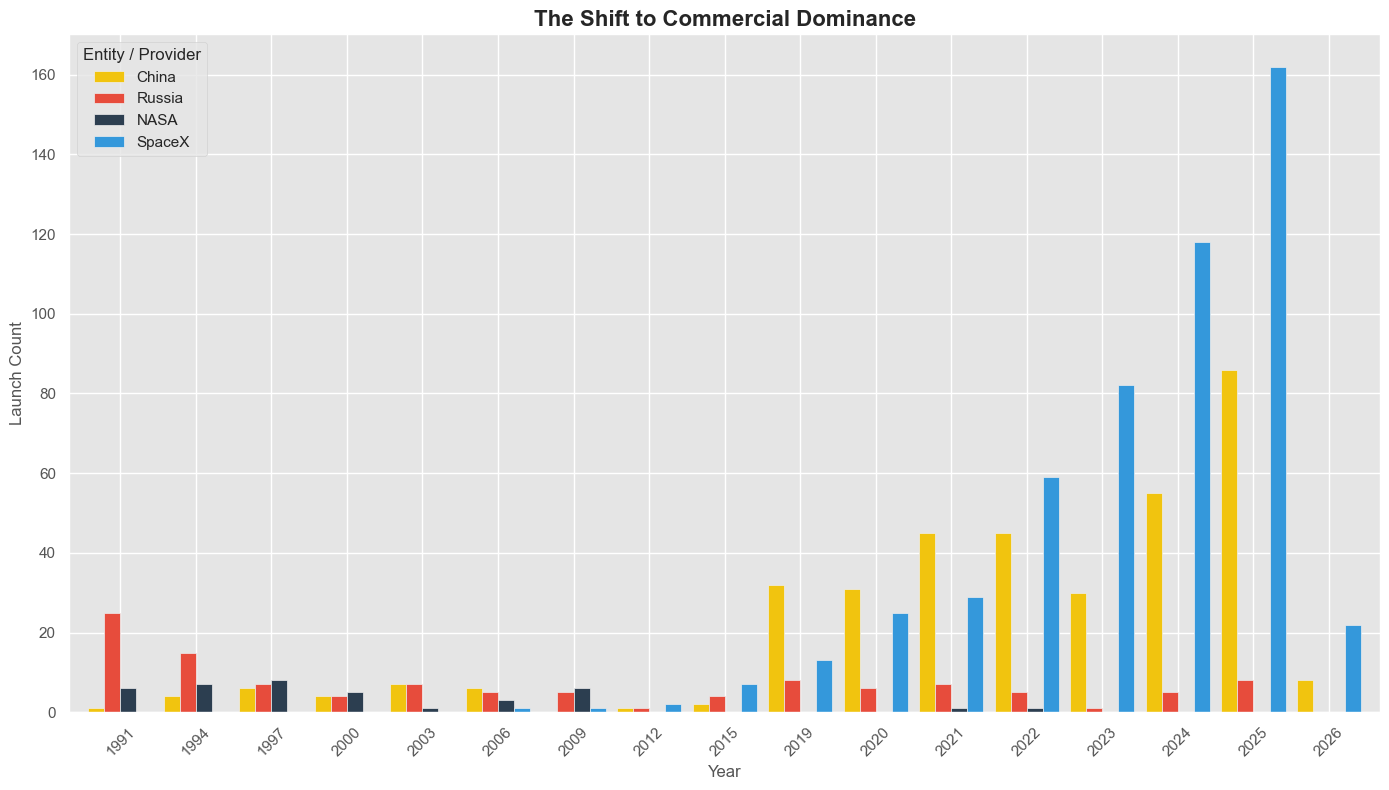

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter base date range
df_modern = space_df[(space_df['date'] >= 1990) & (space_df['date'] <= 2026)].copy()

# 2. Define Mapping Logic
def map_to_focus_groups(row):
    company = str(row['Company Name']).strip()
    country = str(row['countries']).strip()
    
    if country == 'China':
        return 'China'
    
    if country in ['Russia', 'USSR', 'Russia/USSR']:
        return 'Russia'
    
    if 'SpaceX' in company:
        return 'SpaceX'
    
    if 'NASA' in company:
        return 'NASA'
    
    if 'ULA' in company:
        return 'ULA'
    
    return 'Other'

df_modern['Focus_Group'] = df_modern.apply(map_to_focus_groups, axis=1)

df_filtered = df_modern[df_modern['Focus_Group'] != 'Other'].copy()

# 3. Keep ONLY the specific early years + all years after 2000
early_years = [1991, 1994, 1997, 2000, 2003, 2006, 2009, 2012, 2015, 2019, 2022, 2025]
post_2000_years = list(range(2020, 2027))

years_to_keep = early_years + post_2000_years

df_filtered = df_filtered[df_filtered['date'].isin(years_to_keep)]

# 4. Pivot normally (no grouping)
pivot_focus = (
    df_filtered
    .groupby(['date', 'Focus_Group'])
    .size()
    .unstack(fill_value=0)
)

pivot_focus = pivot_focus.sort_index()

# 5. Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    'China': '#f1c40f',
    'Russia': '#e74c3c',
    'NASA': '#2c3e50',
    'SpaceX': '#3498db',
    'United Launch Alliance': '#9b59b6'
}

plot_cols = [c for c in colors.keys() if c in pivot_focus.columns]

pivot_focus[plot_cols].plot(
    kind='bar',
    stacked=False,
    ax=ax,
    width=0.85,
    color=[colors[c] for c in plot_cols]
)

# Formatting
ax.set_title('The Shift to Commercial Dominance', fontsize=16, fontweight='bold')
ax.set_ylabel('Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(title="Entity / Provider")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\nmill\AppData\Local\Temp\ipykernel_45868\3968261791.py:77: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



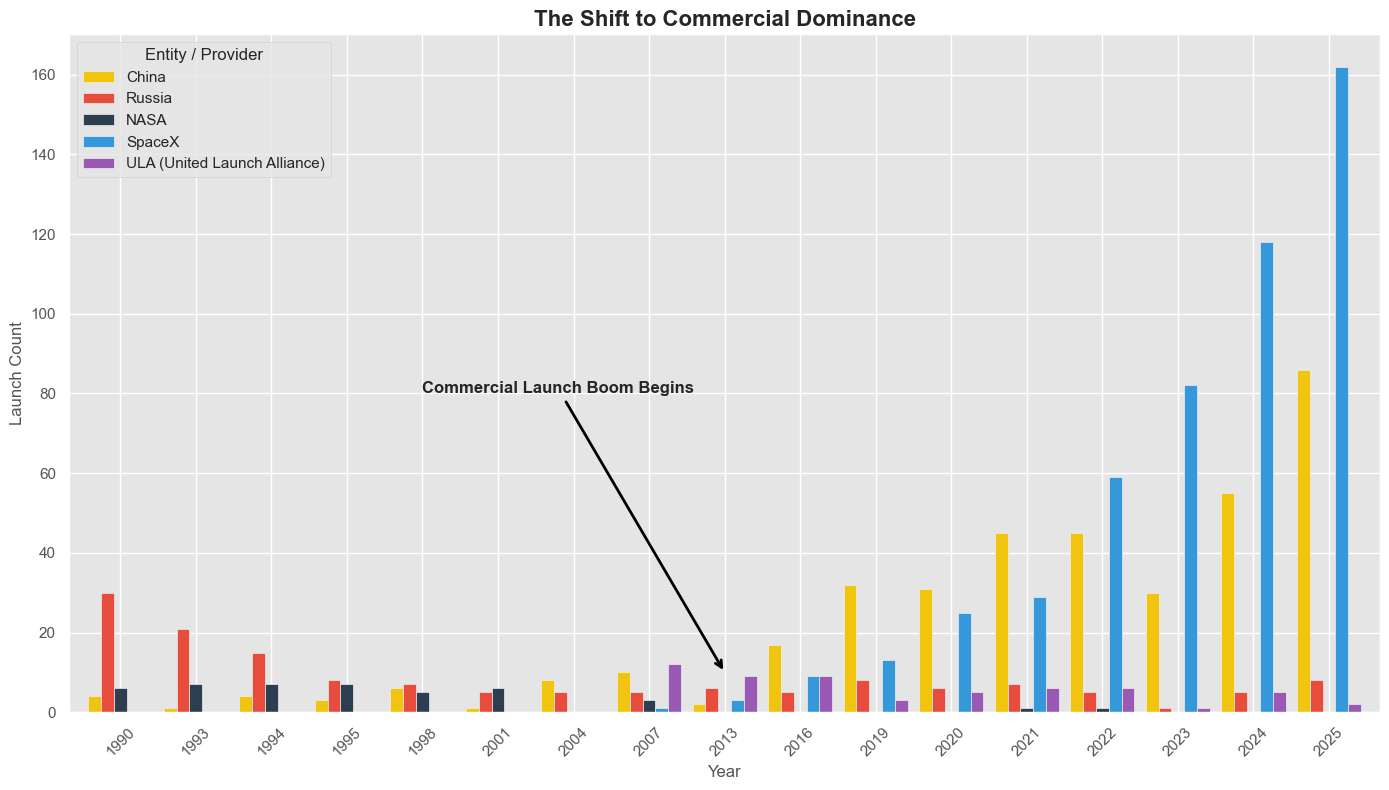

In [147]:

import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter base date range
df_modern = space_df[(space_df['date'] >= 1990) & (space_df['date'] <= 2026)].copy()

# 2. Define Mapping Logic
def map_to_focus_groups(row):
    company = str(row['Company Name']).strip()
    country = str(row['countries']).strip()
    
    if country == 'China':
        return 'China'
    
    if country in ['Russia', 'USSR', 'Russia/USSR']:
        return 'Russia'
    
    if 'SpaceX' in company:
        return 'SpaceX'
    
    if 'NASA' in company:
        return 'NASA'
    
    if 'ULA' in company or 'United Launch Alliance' in company:
        return 'ULA (United Launch Alliance)'
    
    return 'Other'

# Apply mapping
df_modern['Focus_Group'] = df_modern.apply(map_to_focus_groups, axis=1)

# Filter out "Other"
df_filtered = df_modern[df_modern['Focus_Group'] != 'Other'].copy()

# 3. Select specific years to display
early_years = [1990, 1993, 1994, 1995, 1998, 2001, 2004, 2007, 2013, 2016]
post_2000_years = list(range(2019, 2026))

years_to_keep = early_years + post_2000_years
df_filtered = df_filtered[df_filtered['date'].isin(years_to_keep)]

# 4. Pivot data
pivot_focus = (
    df_filtered
    .groupby(['date', 'Focus_Group'])
    .size()
    .unstack(fill_value=0)
)

pivot_focus = pivot_focus.sort_index()

# 5. Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    'China': '#f1c40f',
    'Russia': '#e74c3c',
    'NASA': '#2c3e50',
    'SpaceX': '#3498db',
    'ULA (United Launch Alliance)': '#9b59b6'
}

plot_cols = [c for c in colors.keys() if c in pivot_focus.columns]

pivot_focus[plot_cols].plot(
    kind='bar',
    stacked=False,
    ax=ax,
    width=0.85,
    color=[colors[c] for c in plot_cols]
)

# 🔽 Arrow showing transition to commercial era (~2013)
transition_x = pivot_focus.index.get_loc(2013)

ax.annotate(
    'Commercial Launch Boom Begins',
    xy=(transition_x, 10),        # where arrow points
    xytext=(transition_x - 4, 80), # where text sits
    arrowprops=dict(
        facecolor='black',
        arrowstyle='->', 
        color='black',
        linewidth=2
    ),
    fontsize=12,
    fontweight='bold'
)

# Formatting
ax.set_title('The Shift to Commercial Dominance', fontsize=16, fontweight='bold')
ax.set_ylabel('Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(title="Entity / Provider")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [130]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date,Lat,Lon,provider
1179,Roscosmos,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Mon Dec 03, 2018 11:31 UTC",Soyuz FG | Soyuz MS-11 (57S),StatusRetired,0.0,Success,Kazakhstan,2018,45.9697,63.3042,State
